# Structural Equation Modeling: Integrating Brain Metrics and Personality

This notebook represents the final stage of the analytical pipeline: the Structural Equation Model (SEM). In this step, we integrate the two primary streams of our project - psychometric latent structures and neuroimaging network metrics - into a single, comprehensive predictive model.

The analysis utilizes the **optimal bifactor structure** of neuroticism identified in the `measurement_models` stage, characterized by a general neuroticism factor and specific facets for anxiety and depression. These latent constructs are predicted by a subset of **global brain measures**, which were selected based on correlation heatmap inspection to minimize multicollinearity.

The outputs displayed here represent **real analytical results**. Since all reported parameters are aggregate statistical estimates, the privacy of the participants is fully maintained in accordance with the HCP Restricted Data Use Agreement.

### Reproducibility Note
To replicate these findings or apply this pipeline to new data, researchers must ensure the following:
- **Data Linkage**: This notebook reads in the real prepped behavioral data and the aggregated brain measure CSV
- **Subject Identifiers**: Note that while the `brain_measures_for_SEM` CSV provided in this repository contains the authentic calculated metrics, the Subject column has been anonymized. To successfully execute the SEM integration, the Subject column in both the behavioral and neuroimaging dataframes must contain matching, authentic HCP subject IDs.

---
### Preparing Env and Data

In [1]:
# Set-Up
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)
from IPython.display import Image, display
from rpy2 import robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr
pandas2ri.activate()
numpy2ri.activate()
ro.r('set.seed(123)')
%load_ext rpy2.ipython
importr('base')
importr('lavaan')
importr('semPlot')

rpy2.robjects.packages.Package as a <module 'semPlot'>

In [ ]:
# Load neuroticism and brain data
# IMPORTANT: Update both paths below for your environment.
# neuroticism_df: path to your local version of the prepped official data
# brain_measures_df: path to your version of aggregated brain measures containing the OFFICIAL SUBJECT IDs
neuroticism_df = pd.read_csv(r"YOUR\PATH\HERE\prepped_RESTRICTED_neuroticism_data_for_SEM.csv", dtype={'Subject': str})
brain_measures_df = pd.read_csv(r"YOUR\PATH\HERE\aggregated_brain_measures_for_SEM.csv", dtype={'Subject': str})

# Merge into one df
sem_df = pd.merge(
    neuroticism_df, 
    brain_measures_df, 
    on='Subject', 
    how='inner' # uses intersection -> only subjects with both neuroticism and MRI data included
)
print(sem_df.shape)
print(f"\nColumns:\n{sem_df.columns.tolist()}")

# Sanity check
common_subjects = set(brain_measures_df['Subject']).intersection(set(neuroticism_df['Subject']))
print(f"\n The final df contains intersection of subjects of both dfs: {len(common_subjects) == len(sem_df)}")

# Put into R
ro.globalenv['sem_df'] = sem_df

(1053, 22)

Columns:
['Subject', 'NEORAW_01', 'NEORAW_06', 'NEORAW_11', 'NEORAW_16', 'NEORAW_21', 'NEORAW_26', 'NEORAW_31', 'NEORAW_36', 'NEORAW_41', 'NEORAW_46', 'NEORAW_51', 'NEORAW_56', 'Stat_Eff_AUC', 'Stat_SWP_AUC', 'Stat_Clust_AUC', 'Stat_Stre_AUC', 'Stat_Betw_AUC', 'Stat_Part_AUC', 'Dyn_EffVar_AUC', 'Dyn_MeanBOLD_Var', 'Dyn_MeanEdge_Var']

 The final df contains intersection of subjects of both dfs: True


### Fitting the SEM 
SEM with chosen brain measures:
- Global Efficiency
- Betweenness Centrality
- Participation Coefficient
- Global Efficiency Variability
- Mean BOLD Variability

In [3]:
# Create equation of all neuroticism items
nums = [1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56]
neuro_cols = [f"NEORAW_{i:02d}" for i in nums]
neuro_equation = " + ".join(neuro_cols)

# Lavaan model specification
model_specification_5 = f"""
    # Measurement Model: Latent Variables
    # general neuroticism factor and two specific facets defined by their strongest items
    g     =~ {neuro_equation}           # general neuroticism (all items)
    s_anx =~ a*NEORAW_01 + a*NEORAW_31  # anxiety facet (constrained loadings)
    s_dep =~ b*NEORAW_16 + b*NEORAW_46  # depression facet (constrained loadings)

    # Structural Model: Brain-Behavior Regressions
    # predict latent traits using brain metrics
    g     ~ Stat_Eff_AUC + Stat_Betw_AUC + Stat_Part_AUC + Dyn_EffVar_AUC + Dyn_MeanBOLD_Var
    s_anx ~ Stat_Eff_AUC + Stat_Betw_AUC + Stat_Part_AUC + Dyn_EffVar_AUC + Dyn_MeanBOLD_Var
    s_dep ~ Stat_Eff_AUC + Stat_Betw_AUC + Stat_Part_AUC + Dyn_EffVar_AUC + Dyn_MeanBOLD_Var
    
"""
ro.globalenv['model_specification_5'] = model_specification_5

In [4]:
%%R
sem_fit_5 <- sem(model_specification_5, data = sem_df, orthogonal=TRUE, std.lv=TRUE)
sem_fit_5@Fit@converged # check, model did converge

[1] TRUE


In [5]:
%%R
summary(sem_fit_5, fit.measures = TRUE, standardized=TRUE)

lavaan 0.6-20 ended normally after 48 iterations

  Estimator                                         ML
  Optimization method                           NLMINB
  Number of model parameters                        43
  Number of equality constraints                     2

  Number of observations                          1053

Model Test User Model:
                                                      
  Test statistic                               291.881
  Degrees of freedom                                97
  P-value (Chi-square)                           0.000

Model Test Baseline Model:

  Test statistic                              3359.162
  Degrees of freedom                               126
  P-value                                        0.000

User Model versus Baseline Model:

  Comparative Fit Index (CFI)                    0.940
  Tucker-Lewis Index (TLI)                       0.922

Loglikelihood and Information Criteria:

  Loglikelihood user model (H0)             -163

### Model Visualization

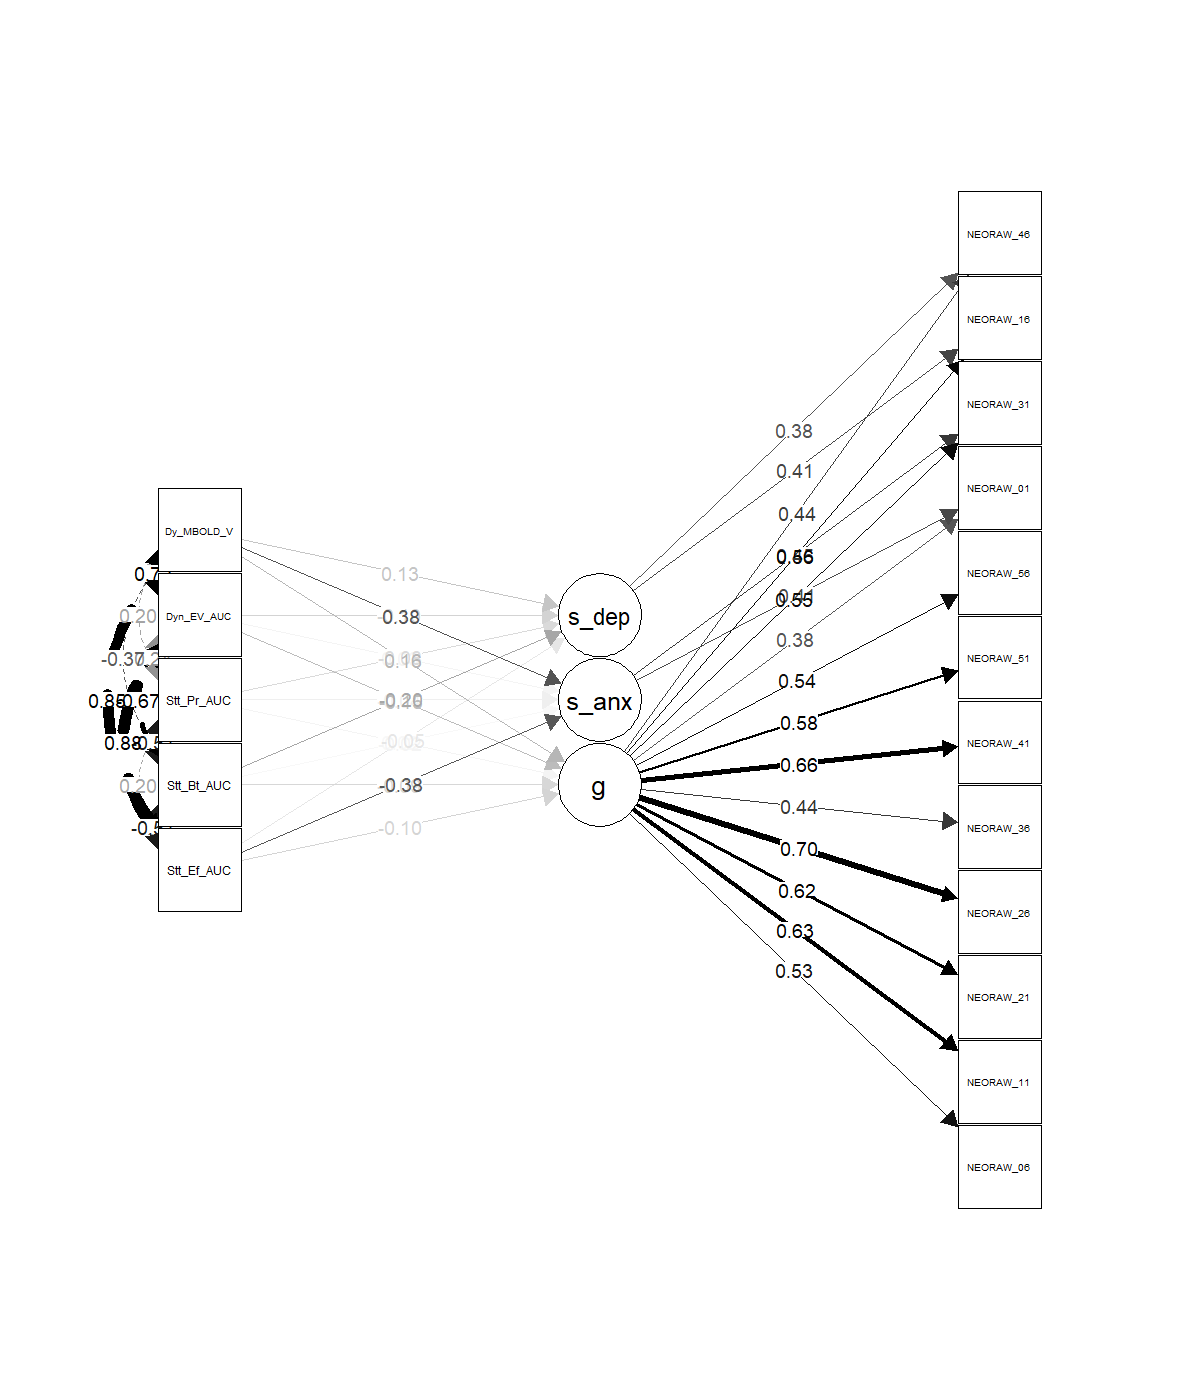

In [6]:
ro.r("""
library(semPlot)
png("sem_plot.png", width=1200, height=1400, res=120)
semPaths(sem_fit_5,
         what="std",
         layout = "tree2",       
         residuals = FALSE,     
         rotation = 2,          
         nCharNodes = 10,        
         sizeMan = 6,            
         sizeLat = 6,            
         node.label.cex = 0.8,   
         edge.color = "black"         
)
dev.off()
""")

display(Image("sem_plot.png"))